# Neural Network (MLP) with PyTorch

Full PyTorch pipeline: `nn.Module`, `DataLoader`, `Adam`, training loop with
early stopping, learning rate scheduling, and dropout.

**Dataset:** Breast Cancer  
**Model saved to:** `../Models/nn_pytorch.pth`

In [1]:
!pip install torch -q

## 1. Imports & Data

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

torch.manual_seed(42)
np.random.seed(42)

data     = load_breast_cancer()
X_raw, y = data.data, data.target
class_names = list(data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Using device: cpu
Train: 455  |  Test: 114


## 2. PyTorch Datasets & DataLoaders

In [3]:
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32).to(DEVICE),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(DEVICE))

X_tr_t, y_tr_t = to_tensor(X_train_sc, y_train)
X_te_t, y_te_t = to_tensor(X_test_sc,  y_test)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=32, shuffle=True
)

## 3. Define the MLP

`nn.Module` approach — defines `forward()`, PyTorch handles backprop automatically
via its autograd engine (builds a computation graph during forward pass,
then calls `.backward()` to traverse it in reverse).

In [4]:
class MLP(nn.Module):
    def __init__(self, n_in, hidden_sizes, dropout=0.3):
        super().__init__()
        layers = []
        in_dim = n_in
        for h in hidden_sizes:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))   # no sigmoid — BCEWithLogitsLoss is more stable
        self.net = nn.Sequential(*layers)

        # He initialisation
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


model = MLP(n_in=30, hidden_sizes=[64, 32], dropout=0.3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 4,289


## 4. Loss, Optimiser & Scheduler

In [5]:
criterion = nn.BCEWithLogitsLoss()        # sigmoid + BCE fused — more numerically stable
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20
)

## 5. Training Loop with Early Stopping

In [6]:
EPOCHS        = 300
PATIENCE      = 30

best_val_loss = float('inf')
patience_ctr  = 0
best_state    = None
history       = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    batch_losses = []
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()          # PyTorch autograd computes all gradients
        optimizer.step()
        batch_losses.append(loss.item())

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        tr_logits = model(X_tr_t)
        va_logits = model(X_te_t)
        tr_loss   = criterion(tr_logits, y_tr_t).item()
        va_loss   = criterion(va_logits, y_te_t).item()
        tr_acc    = ((tr_logits.sigmoid() >= 0.5) == y_tr_t).float().mean().item()
        va_acc    = ((va_logits.sigmoid() >= 0.5) == y_te_t).float().mean().item()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    scheduler.step(va_loss)

    # ── Early stopping ────────────────────────────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:>4} | loss: {tr_loss:.4f} | val_loss: {va_loss:.4f} "
              f"| val_acc: {va_acc:.4f} | lr: {optimizer.param_groups[0]['lr']:.2e}")

# Restore best weights
model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch    1 | loss: 0.5842 | val_loss: 0.5918 | val_acc: 0.7456 | lr: 1.00e-03
Epoch   50 | loss: 0.0445 | val_loss: 0.0839 | val_acc: 0.9825 | lr: 1.00e-03
Epoch  100 | loss: 0.0271 | val_loss: 0.0787 | val_acc: 0.9737 | lr: 5.00e-04
Early stopping at epoch 138

Best val loss: 0.0732


## 6. Loss & Accuracy Curves

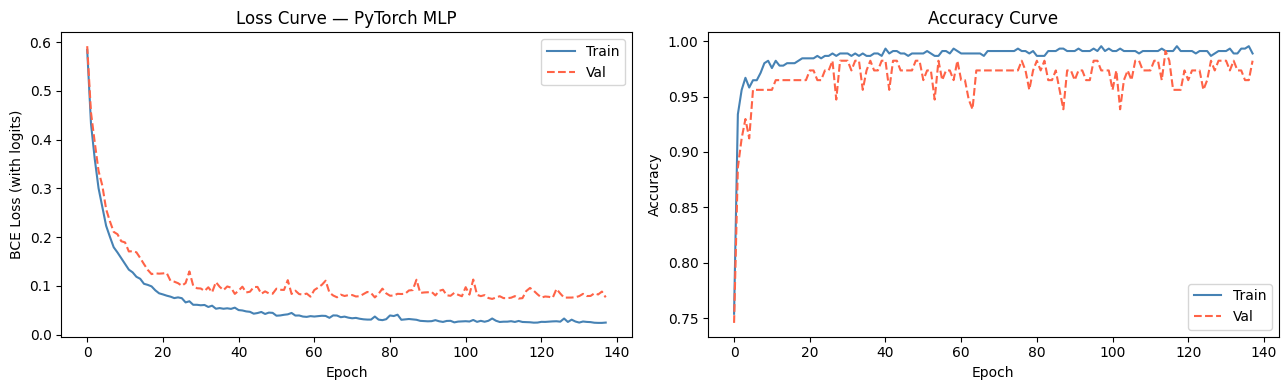

In [7]:
epochs_ran = len(history['train_loss'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['train_loss'], label='Train', color='steelblue')
ax1.plot(history['val_loss'],   label='Val',   color='tomato', linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss (with logits)')
ax1.set_title('Loss Curve — PyTorch MLP'); ax1.legend()

ax2.plot(history['train_acc'], label='Train', color='steelblue')
ax2.plot(history['val_acc'],   label='Val',   color='tomato', linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve'); ax2.legend()

plt.tight_layout(); plt.show()

## 7. Evaluation

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

ROC-AUC: 0.9960


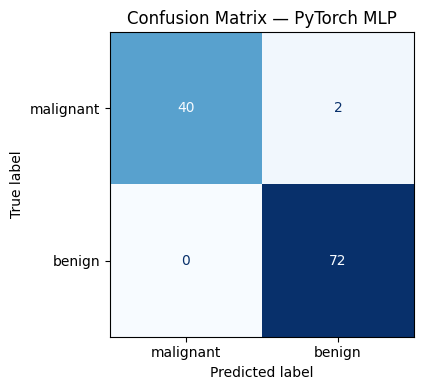

In [8]:
model.eval()
with torch.no_grad():
    logits = model(X_te_t).cpu().numpy().flatten()

y_proba = 1 / (1 + np.exp(-logits))   # sigmoid
y_pred  = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=class_names))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — PyTorch MLP')
plt.tight_layout(); plt.show()

## 8. Architecture Comparison (Depth & Width)

In [9]:
configs = {
    'Shallow [16]':      [16],
    'Medium [64,32]':    [64, 32],
    'Deep [128,64,32]':  [128, 64, 32],
    'Wide [256,128]':    [256, 128],
}

print(f"{'Architecture':<22} {'Val Acc':>8} {'Params':>8}")
print('-' * 42)
for name, hidden in configs.items():
    torch.manual_seed(42)
    m = MLP(30, hidden, dropout=0.2).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(200):
        m.train()
        for Xb, yb in train_loader:
            opt.zero_grad()
            criterion(m(Xb), yb).backward()
            opt.step()
    m.eval()
    with torch.no_grad():
        logits = m(X_te_t)
        acc    = ((logits.sigmoid() >= 0.5) == y_te_t).float().mean().item()
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:<22} {acc:>8.4f} {params:>8,}")

Architecture            Val Acc   Params
------------------------------------------
Shallow [16]             0.9649      545
Medium [64,32]           0.9825    4,289
Deep [128,64,32]         0.9825   14,785
Wide [256,128]           0.9737   41,729


## 9. Save Model to `../Models/`

In [10]:
# Save weights separately (pure tensors — works with weights_only=True)
torch.save(model.state_dict(), '../Models/nn_pytorch_weights.pth')

# Save config/metadata as JSON (no pickle, no numpy, no compatibility issues)
import json as _json
config = {
    'architecture':  {'n_in': 30, 'hidden_sizes': [64, 32], 'dropout': 0.3},
    'scaler_mean':   scaler.mean_.tolist(),
    'scaler_std':    scaler.scale_.tolist(),
    'class_names':   class_names
}
with open('../Models/nn_pytorch_config.json', 'w') as f_cfg:
    _json.dump(config, f_cfg)

w_kb  = os.path.getsize('../Models/nn_pytorch_weights.pth') / 1024
cf_kb = os.path.getsize('../Models/nn_pytorch_config.json') / 1024
print(f'Saved weights → ../Models/nn_pytorch_weights.pth  ({w_kb:.1f} KB)')
print(f'Saved config  → ../Models/nn_pytorch_config.json  ({cf_kb:.1f} KB)')

Saved weights → ../Models/nn_pytorch_weights.pth  (23.3 KB)
Saved config  → ../Models/nn_pytorch_config.json  (1.3 KB)


## 10. Reload & Verify

In [11]:
import json as _json

with open('../Models/nn_pytorch_config.json') as f_cfg:
    config = _json.load(f_cfg)

arch = config['architecture']
model_loaded = MLP(arch['n_in'], arch['hidden_sizes'], arch['dropout'])

# weights_only=True is safe — the .pth contains only tensors, no arbitrary objects
state = torch.load('../Models/nn_pytorch_weights.pth',
                   map_location='cpu', weights_only=True)
model_loaded.load_state_dict(state)
model_loaded.eval()

with torch.no_grad():
    logits_r = model_loaded(X_te_t.cpu()).numpy().flatten()

acc_r = ((1 / (1 + np.exp(-logits_r))) >= 0.5) == y_test
print(f'Reloaded model test accuracy: {acc_r.mean():.4f}')

Reloaded model test accuracy: 0.9825
